# Basic EDA and Model Evaluation

This notebook explores the processed face dataset and evaluates the FaceNet + SVM classifier using a stratified train/test split.

In [4]:
# Install EDA dependencies into the active Jupyter kernel.
# Run this cell once, then continue with the imports below.
%pip install -q joblib numpy pandas matplotlib seaborn Pillow scikit-learn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
from pathlib import Path
import hashlib
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

# Works when Jupyter starts from either the repository root or notebooks/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'dataset').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_DIR = PROJECT_ROOT / 'dataset' / 'processed'
EMBEDDINGS_PATH = PROJECT_ROOT / 'models' / 'embeddings.pkl'
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
RANDOM_STATE = 42
TEST_SIZE = 0.20

print('Project root:', PROJECT_ROOT.resolve())
print('Dataset:', DATASET_DIR.resolve())

Project root: /home/mehedinaeem/Desktop/Code/Hybrid_Attendance_System
Dataset: /home/mehedinaeem/Desktop/Code/Hybrid_Attendance_System/dataset/processed


## 1. Build the image inventory

In [6]:
if not DATASET_DIR.exists():
    raise FileNotFoundError(f'Dataset directory not found: {DATASET_DIR.resolve()}')

records = []
for student_dir in sorted(DATASET_DIR.iterdir()):
    if not student_dir.is_dir():
        continue
    for image_path in sorted(student_dir.iterdir()):
        if image_path.suffix.lower() not in VALID_EXTENSIONS:
            continue
        record = {
            'student_id': student_dir.name,
            'image_path': str(image_path),
            'file_name': image_path.name,
            'extension': image_path.suffix.lower(),
            'file_size_kb': image_path.stat().st_size / 1024,
            'width': np.nan, 'height': np.nan, 'channels': np.nan,
            'is_valid': False, 'error': None
        }
        try:
            with Image.open(image_path) as image:
                record['width'], record['height'] = image.size
                record['channels'] = len(image.getbands())
                image.verify()
                record['is_valid'] = True
        except Exception as error:
            record['error'] = str(error)
        records.append(record)

df = pd.DataFrame(records)
if df.empty:
    raise ValueError(f'No supported image files found in {DATASET_DIR.resolve()}')

display(df.head())

,student_id,image_path,file_name,extension,file_size_kb,width,height,channels,is_valid,error
0,22102001,/home/mehedinaeem/Desktop/Code/Hybrid_Attendan...,22102001_face_001.jpg,.jpg,11.560547,160,160,3,True,None
1,22102001,/home/mehedinaeem/Desktop/Code/Hybrid_Attendan...,22102001_face_002.jpg,.jpg,11.046875,160,160,3,True,None
2,22102001,/home/mehedinaeem/Desktop/Code/Hybrid_Attendan...,22102001_face_003.jpg,.jpg,12.290039,160,160,3,True,None
3,22102001,/home/mehedinaeem/Desktop/Code/Hybrid_Attendan...,22102001_face_004.jpg,.jpg,14.009766,160,160,3,True,None
4,22102001,/home/mehedinaeem/Desktop/Code/Hybrid_Attendan...,22102001_face_005.jpg,.jpg,14.428711,160,160,3,True,None


## 2. Dataset totals and quality checks

In [7]:
class_distribution = (df.groupby('student_id').size()
                      .reset_index(name='image_count')
                      .sort_values('image_count', ascending=False))
total_students = df['student_id'].nunique()
total_images = len(df)
valid_images = int(df['is_valid'].sum())
invalid_images = total_images - valid_images

summary = pd.DataFrame({
    'Metric': ['Total students/classes', 'Total images', 'Valid images',
               'Invalid/corrupted images', 'Average images per student',
               'Minimum images in a class', 'Maximum images in a class',
               'Dataset size (MB)'],
    'Value': [total_students, total_images, valid_images, invalid_images,
              round(total_images / total_students, 2),
              int(class_distribution['image_count'].min()),
              int(class_distribution['image_count'].max()),
              round(df['file_size_kb'].sum() / 1024, 2)]
})
display(summary)
display(class_distribution)

,Metric,Value
0,Total students/classes,10.00
1,Total images,446.00
2,Valid images,446.00
3,Invalid/corrupted images,0.00
4,Average images per student,44.60
5,Minimum images in a class,7.00
6,Maximum images in a class,67.00
7,Dataset size (MB),5.24


,student_id,image_count
2,22102017,67
4,22102024,64
3,22102023,61
1,22102013,58
7,22102027,47
8,22102029,39
6,22102026,38
5,22102025,38
0,22102001,27
9,22102042,7


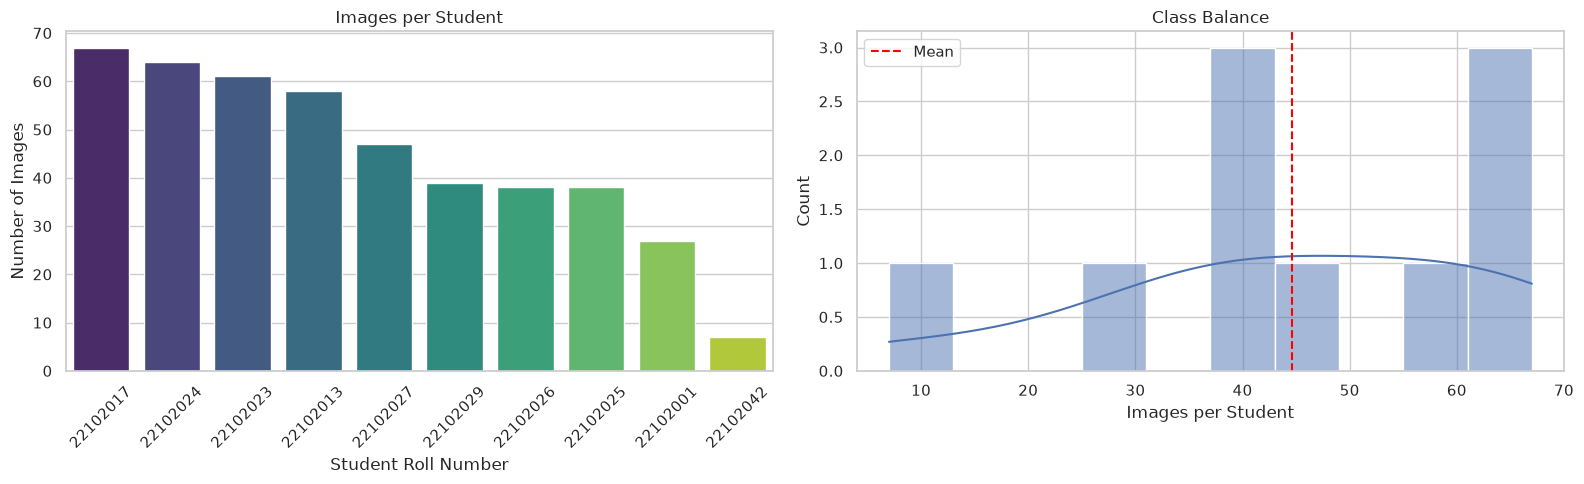

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=class_distribution, x='student_id', y='image_count',
            hue='student_id', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Images per Student')
axes[0].set_xlabel('Student Roll Number')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=45)
sns.histplot(class_distribution['image_count'], bins=min(15, total_students),
             kde=total_students > 2, ax=axes[1])
axes[1].axvline(class_distribution['image_count'].mean(), color='red',
                linestyle='--', label='Mean')
axes[1].set_title('Class Balance')
axes[1].set_xlabel('Images per Student')
axes[1].legend()
plt.tight_layout()
plt.show()

In [9]:
valid_df = df[df['is_valid']].copy()
valid_df['resolution'] = (valid_df['width'].astype(int).astype(str) + ' x ' +
                          valid_df['height'].astype(int).astype(str))
print('Image properties:')
display(valid_df[['width', 'height', 'channels', 'file_size_kb']].describe().round(2))
print('Most common resolutions:')
display(valid_df['resolution'].value_counts().head(10).to_frame('count'))
print('Invalid/corrupted files:')
display(df.loc[~df['is_valid'], ['student_id', 'image_path', 'error']])

Image properties:


,width,height,channels,file_size_kb
count,446.0,446.0,446.0,446.00
mean,160.0,160.0,3.0,12.03
std,0.0,0.0,0.0,1.67
min,160.0,160.0,3.0,6.57
25%,160.0,160.0,3.0,11.16
50%,160.0,160.0,3.0,12.24
75%,160.0,160.0,3.0,13.12
max,160.0,160.0,3.0,17.01


Most common resolutions:


,count
resolution,
160 x 160,446


Invalid/corrupted files:


,student_id,image_path,error


## 3. Random image samples

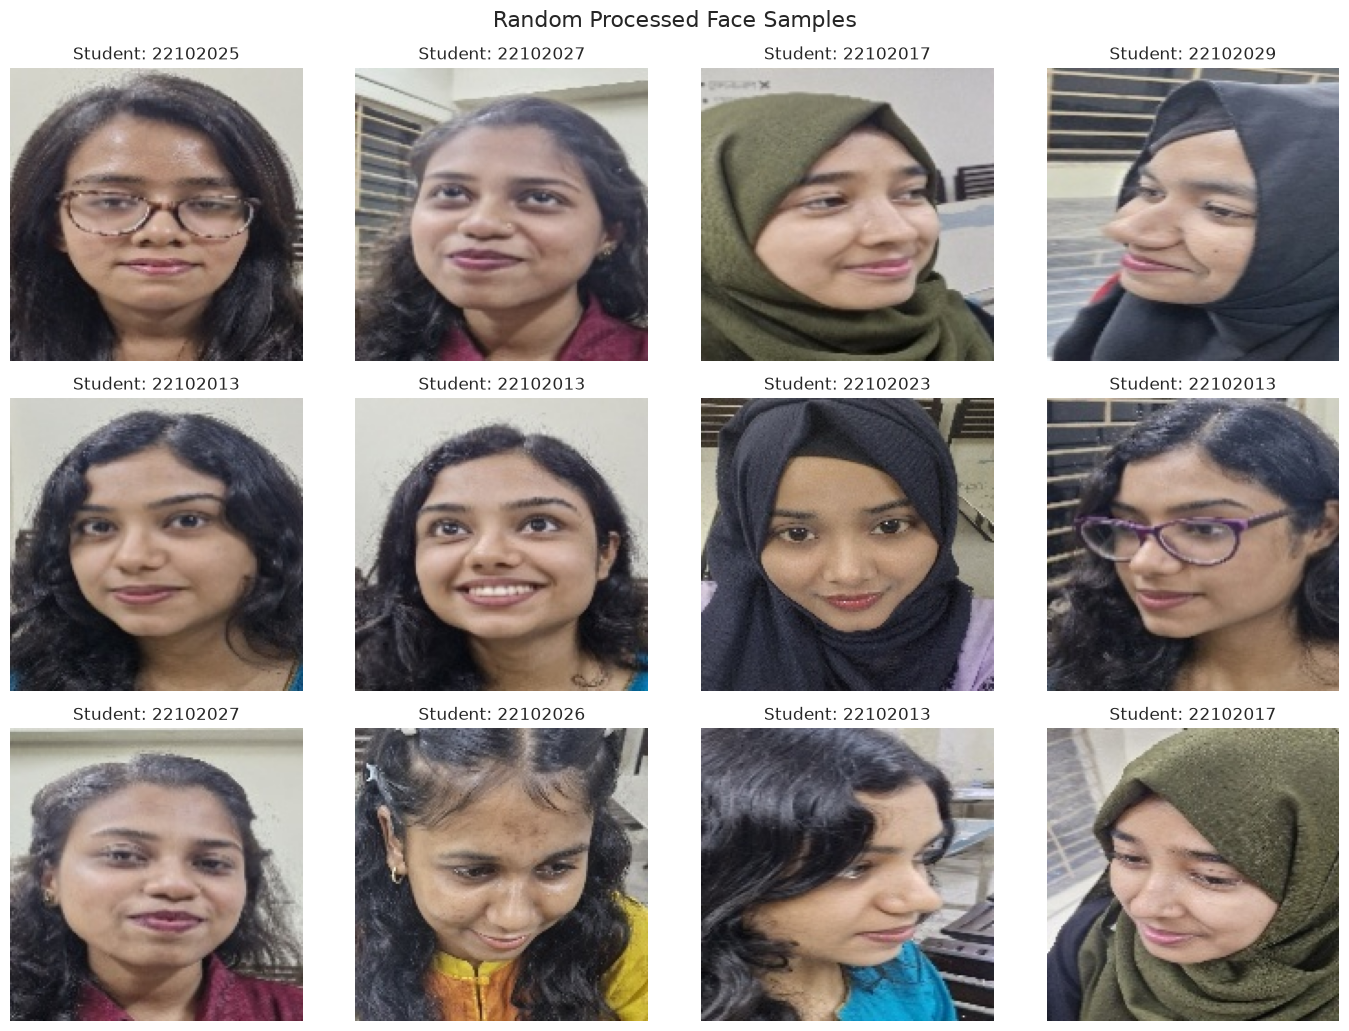

In [19]:
sample = valid_df.sample(n=min(12, len(valid_df)), random_state=RANDOM_STATE)
columns = 4
rows = int(np.ceil(len(sample) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(14, 3.5 * rows), squeeze=False)
axes = axes.ravel()
for axis, (_, row) in zip(axes, sample.iterrows()):
    with Image.open(row['image_path']) as image:
        axis.imshow(image.convert('RGB'))
    axis.set_title(f"Student: {row['student_id']}")
    axis.axis('off')
for axis in axes[len(sample):]:
    axis.axis('off')
plt.suptitle('Random Processed Face Samples', fontsize=16)
plt.tight_layout()
plt.show()

## 4. Exact duplicate detection

In [11]:
def md5_hash(file_path, chunk_size=8192):
    digest = hashlib.md5()
    with open(file_path, 'rb') as file:
        while chunk := file.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()

valid_df['md5'] = valid_df['image_path'].apply(md5_hash)
duplicates = valid_df[valid_df.duplicated('md5', keep=False)].sort_values('md5')
print(f'Files in duplicate groups: {len(duplicates)}')
print(f'Duplicate groups: {duplicates["md5"].nunique()}')
display(duplicates[['student_id', 'file_name', 'image_path', 'md5']])

Files in duplicate groups: 0
Duplicate groups: 0


,student_id,file_name,image_path,md5


## 5. Load and visualize FaceNet embeddings

In [12]:
if not EMBEDDINGS_PATH.exists():
    raise FileNotFoundError(
        f'{EMBEDDINGS_PATH.resolve()} not found. Run scripts/train_model.py first.'
    )

embedding_data = joblib.load(EMBEDDINGS_PATH)
X = np.asarray(embedding_data['embeddings'])
y = np.asarray(embedding_data['labels']).astype(str)

embedding_summary = pd.DataFrame({
    'Metric': ['Total embeddings', 'Embedding dimensions', 'Classes',
               'Missing values', 'Infinite values'],
    'Value': [len(X), X.shape[1], len(np.unique(y)),
              int(np.isnan(X).sum()), int(np.isinf(X).sum())]
})
display(embedding_summary)

,Metric,Value
0,Total embeddings,446
1,Embedding dimensions,128
2,Classes,10
3,Missing values,0
4,Infinite values,0


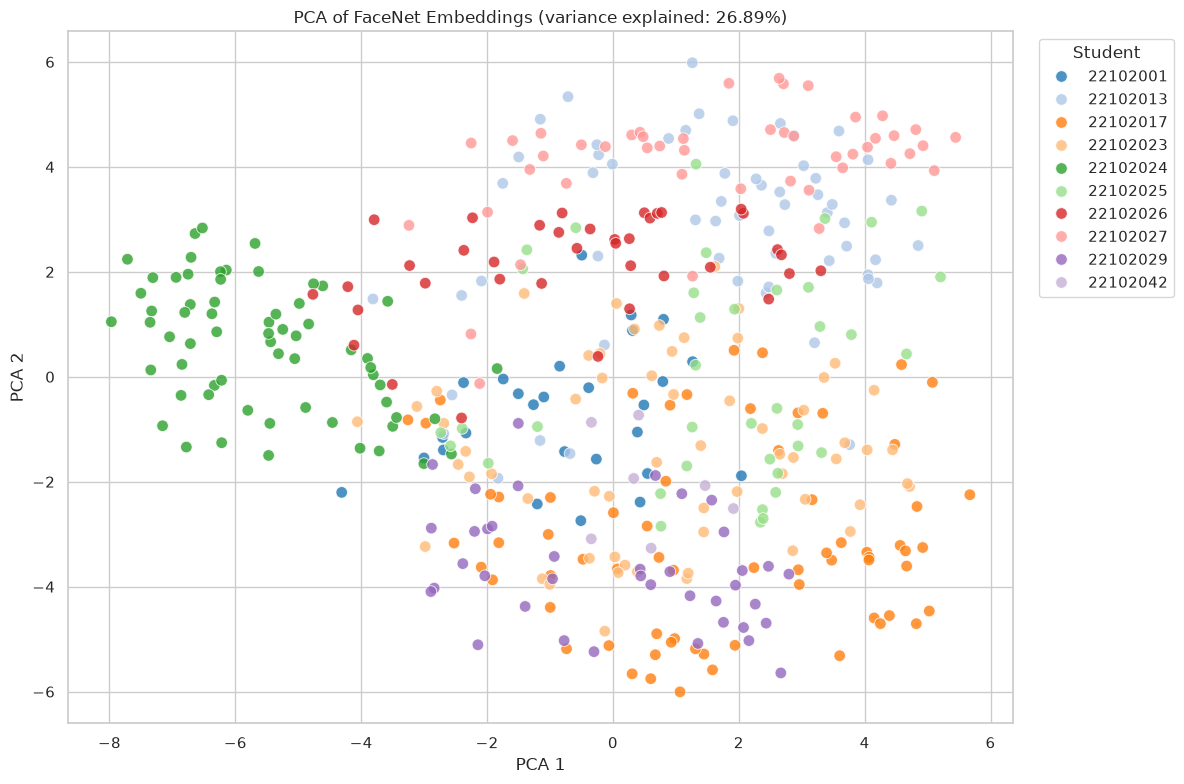

In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
pca_df = pd.DataFrame({'PCA 1': X_pca[:, 0], 'PCA 2': X_pca[:, 1],
                       'student_id': y})
plt.figure(figsize=(12, 8))
sns.scatterplot(data=pca_df, x='PCA 1', y='PCA 2', hue='student_id',
                palette='tab20', s=70, alpha=0.8)
plt.title(f'PCA of FaceNet Embeddings (variance explained: {pca.explained_variance_ratio_.sum():.2%})')
plt.legend(title='Student', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 6. Train the SVM and evaluate performance

In [14]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
encoded_counts = pd.Series(y_encoded).value_counts()
if encoded_counts.min() < 2:
    raise ValueError('Every student needs at least two embeddings for a stratified split.')

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=TEST_SIZE, random_state=RANDOM_STATE,
    stratify=y_encoded
)
classifier = SVC(kernel='linear', probability=True, random_state=RANDOM_STATE)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples:  {len(X_test)}')
print(f'Accuracy:         {accuracy:.2%}')

Training samples: 356
Testing samples:  90
Accuracy:         95.56%


/home/mehedinaeem/Desktop/Code/Bitol_Computer_Vision_System/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [15]:
all_labels = np.arange(len(label_encoder.classes_))
report = classification_report(
    y_test, y_pred, labels=all_labels, target_names=label_encoder.classes_,
    output_dict=True, zero_division=0
)
report_df = pd.DataFrame(report).transpose()
display(report_df.round(4))

,precision,recall,f1-score,support
22102001,0.7143,1.0000,0.8333,5.0000
22102013,1.0000,0.8333,0.9091,12.0000
22102017,1.0000,1.0000,1.0000,14.0000
22102023,1.0000,0.9167,0.9565,12.0000
22102024,1.0000,0.9231,0.9600,13.0000
22102025,0.8000,1.0000,0.8889,8.0000
22102026,1.0000,1.0000,1.0000,8.0000
22102027,1.0000,1.0000,1.0000,9.0000
22102029,1.0000,1.0000,1.0000,8.0000
22102042,1.0000,1.0000,1.0000,1.0000


## 7. Confusion matrices

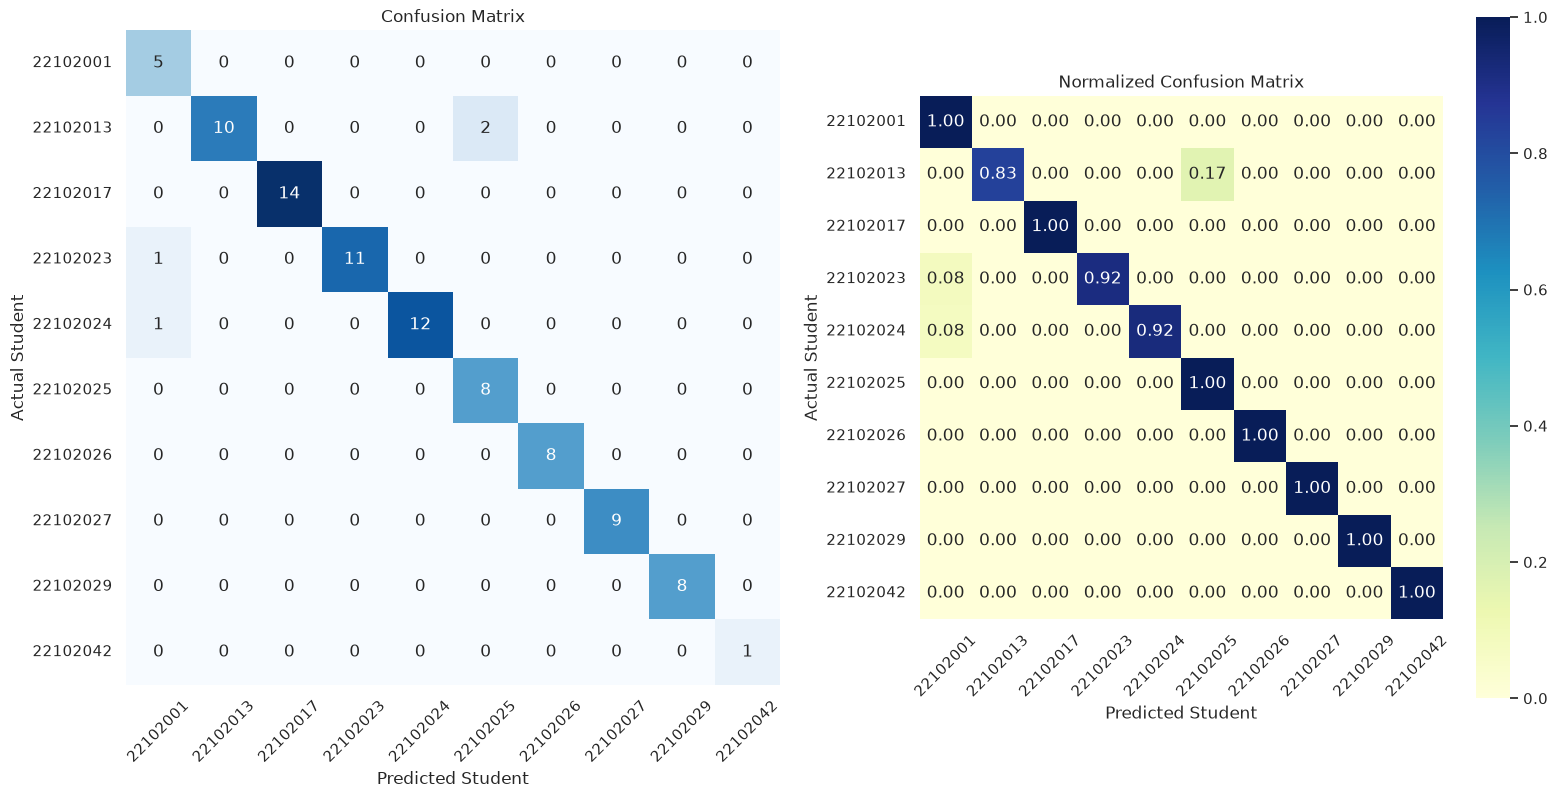

In [16]:
cm = confusion_matrix(y_test, y_pred, labels=all_labels)
cm_normalized = confusion_matrix(y_test, y_pred, labels=all_labels, normalize='true')
size = max(8, len(label_encoder.classes_) * 0.65)
fig, axes = plt.subplots(1, 2, figsize=(size * 2, size))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, square=True,
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted Student')
axes[0].set_ylabel('Actual Student')
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, square=True,
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[1])
axes[1].set_title('Normalized Confusion Matrix')
axes[1].set_xlabel('Predicted Student')
axes[1].set_ylabel('Actual Student')
for axis in axes:
    axis.tick_params(axis='x', rotation=45)
    axis.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

## 8. Incorrect predictions and final summary

In [17]:
predictions = pd.DataFrame({
    'actual': label_encoder.inverse_transform(y_test),
    'predicted': label_encoder.inverse_transform(y_pred)
})
predictions['correct'] = predictions['actual'] == predictions['predicted']
incorrect = predictions[~predictions['correct']].reset_index(drop=True)
print(f'Correct predictions:   {int(predictions["correct"].sum())}')
print(f'Incorrect predictions: {len(incorrect)}')
display(incorrect)

results = pd.DataFrame({
    'Metric': ['Students/classes', 'Total images', 'Valid images', 'Corrupted images',
               'Duplicate files', 'Total embeddings', 'Training samples', 'Testing samples',
               'Correct predictions', 'Incorrect predictions', 'Accuracy',
               'Macro precision', 'Macro recall', 'Macro F1', 'Weighted F1'],
    'Value': [total_students, total_images, valid_images, invalid_images, len(duplicates),
              len(X), len(X_train), len(X_test), int(predictions['correct'].sum()),
              len(incorrect), round(accuracy, 4), round(report['macro avg']['precision'], 4),
              round(report['macro avg']['recall'], 4), round(report['macro avg']['f1-score'], 4),
              round(report['weighted avg']['f1-score'], 4)]
})
display(results)

Correct predictions:   86
Incorrect predictions: 4


,actual,predicted,correct
0,22102024,22102001,False
1,22102023,22102001,False
2,22102013,22102025,False
3,22102013,22102025,False


,Metric,Value
0,Students/classes,10.0000
1,Total images,446.0000
2,Valid images,446.0000
3,Corrupted images,0.0000
4,Duplicate files,0.0000
5,Total embeddings,446.0000
6,Training samples,356.0000
7,Testing samples,90.0000
8,Correct predictions,86.0000
9,Incorrect predictions,4.0000
